## Árboles de decisión

### Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# 2. Definir el clasificador
clf_gs = tree.DecisionTreeClassifier()

# 3. Definir el espacio de búsqueda de hiperparámetros
param_grid_rs = {
    'criterion': ['gini', 'entropy'],  # Criterios de división
    'max_depth': [None, 5, 10, 15, 20], # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10, 15, 17] # Número mínimo de muestras para dividir un nodo
}

In [ ]:
# 4. Configurar y ejecutar GridSearchCV
grid_search = GridSearchCV(
    estimator=clf_gs,
    param_grid=param_grid_rs,
    cv=5,                        # Número de pliegues en la validación cruzada
    verbose=1,                   # Muestra el progreso de la búsqueda
    n_jobs=-1                    # Utiliza todos los núcleos disponibles
)

In [ ]:
x_train["Age"].min()

0.42

In [ ]:
x_train["Age"].max()

80.0

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

#x_train_normalized = pd.DataFrame(scaler.fit_transform(x_train), columns=["Age"])
x_train["Age"]=scaler.fit_transform(x_train["Age"].values.reshape(-1, 1)).reshape(1,-1)[0]
#x_train["Age"]=x_train["Age"]

In [ ]:
x_test["Age"]=scaler.transform(x_test["Age"].values.reshape(-1, 1)).reshape(1,-1)[0]

In [ ]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_split': [2, 5, 10, 15, 17]},
             verbose=1)

In [ ]:
# Obtener el mejor modelo
best_model_gs = grid_search.best_estimator_

# Hacer predicciones
y_pred = best_model_gs.predict(x_test)
#y_pred

Text(50.722222222222214, 0.5, 'True')

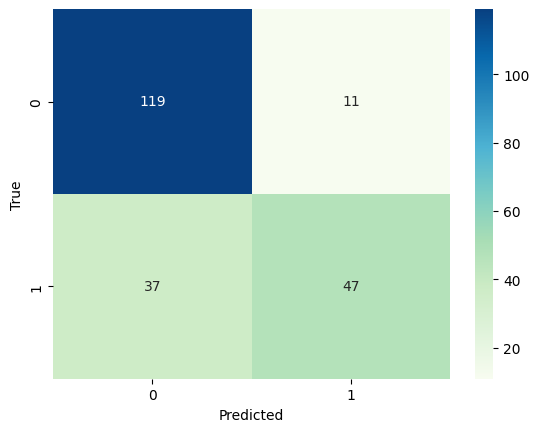

In [ ]:
#Creo la matriz de confusión
tabla=confusion_matrix(y_test, y_pred)

#Grafico la matriz de confusión
sns.heatmap(tabla,cmap='GnBu',annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')

In [ ]:
#Calculo las métricas en el conjunto de evaluación
accuracy=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred,)
f1=f1_score(y_test,y_pred,)

print("Accuracy: "+str(accuracy))
print("Recall: "+str(recall))
print("f1 score: "+str(f1))

Accuracy: 0.7757009345794392
Recall: 0.5595238095238095
f1 score: 0.6619718309859155


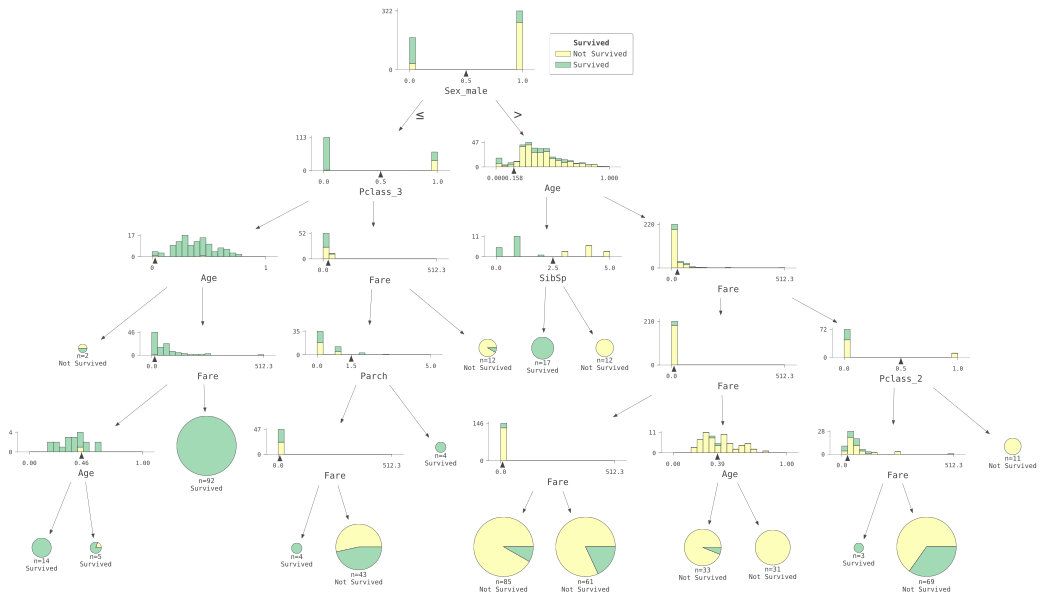

In [ ]:
viz = dtreeviz.model(
    best_model_gs,
    x_train,
    y_train,
    class_names=['Not Survived','Survived'],
    #title="Arbol de Decisión - Titanic dataset",
    target_name='Survived',
    feature_names=x_train.columns.to_list()
    #scale=1.5
    )

viz.view(fontname="monospace")